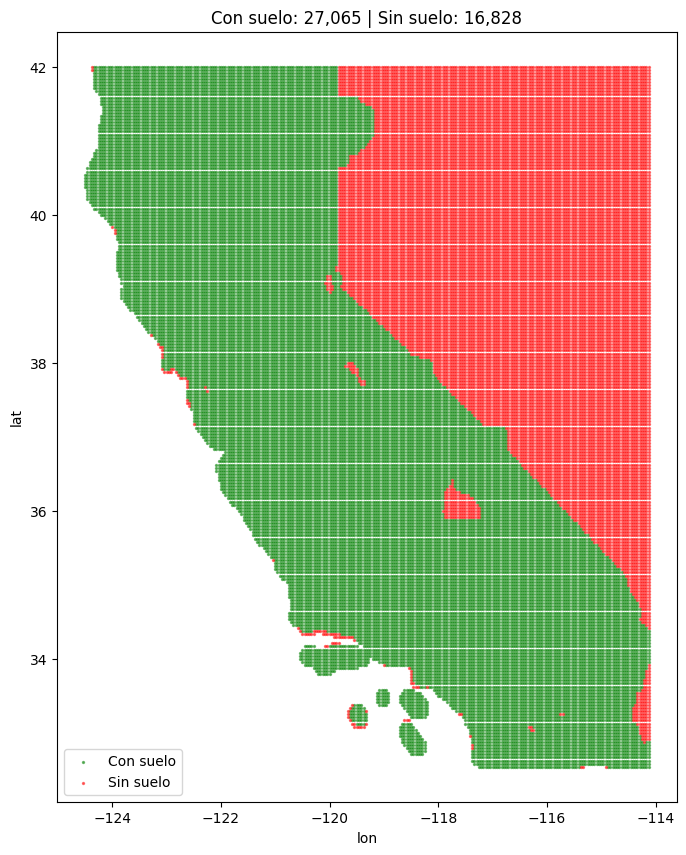

In [1]:
import polars as pl
import matplotlib.pyplot as plt

df = pl.read_parquet(r"C:\Users\lesli\Documents\TFM\Data\base_california_app.parquet")

# Puntos en tierra (con clima)
tierra = df.filter(pl.col("tmax").is_not_null())
con_suelo = tierra.filter(pl.col("ph1to1h2o_r").is_not_null())
sin_suelo = tierra.filter(pl.col("ph1to1h2o_r").is_null())

plt.figure(figsize=(8, 10))
plt.scatter(con_suelo["lon"], con_suelo["lat"], s=2, c="green", label="Con suelo", alpha=0.5)
plt.scatter(sin_suelo["lon"], sin_suelo["lat"], s=2, c="red", label="Sin suelo", alpha=0.5)
plt.legend()
plt.title(f"Con suelo: {con_suelo.height:,} | Sin suelo: {sin_suelo.height:,}")
plt.xlabel("lon"); plt.ylabel("lat")
plt.savefig("mapa_suelo.png", dpi=100)
plt.show()

In [2]:
display(df.head())

lon,lat,tmin,tmax,tmean,ppt,vpdmax,vpdmin,vpdmean,awc_r,ph1to1h2o_r,cec7_r,ecec_r,om_r,ec_r,ksat_r,dbthirdbar_r,sandtotal_r,silttotal_r,claytotal_r,pbray1_r,ptotal_r,sumbases_r,profundidad_efectiva_cm,tmean_245_2030,tmax_245_2030,tmin_245_2030,pr_245_2030,tmean_585_2030,tmax_585_2030,tmin_585_2030,pr_585_2030,tmean_245_2040,tmax_245_2040,tmin_245_2040,pr_245_2040,tmean_585_2040,tmax_585_2040,tmin_585_2040,pr_585_2040,datos_completos
f64,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,bool
-124.5,42.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0,null,null,null,0.0,null,null,null,0.0,null,null,null,0.0,false
-124.458333,42.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0,null,null,null,0.0,null,null,null,0.0,null,null,null,0.0,false
-124.416667,42.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0,null,null,null,0.0,null,null,null,0.0,null,null,null,0.0,false
-124.375,42.0,8.578,13.286,10.932,1698.706055,2.855,0.424,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0,null,null,null,0.0,null,null,null,0.0,null,null,null,0.0,false
-124.333333,42.0,8.578,13.286,10.932,1698.706055,2.855,0.424,null,0.06,8.2,0.1,null,0.0,48.0,91.739998,1.65,99.0,1.0,0.0,null,null,124.6,55.0,13.808796,19.36487,8.252692,0.0,14.22502,19.884123,8.565914,0.0,13.427187,18.630762,8.223624,0.0,13.173934,18.811607,7.536255,0.0,true


In [3]:
import joblib
scaler = joblib.load(r"C:\Users\lesli\Documents\TFM\models\scaler_cluster.pkl")
# Ver las variables que espera el scaler, en orden
if hasattr(scaler, "feature_names_in_"):
    print("Orden de variables del clustering:")
    for i, v in enumerate(scaler.feature_names_in_):
        print(f"  {i}: {v}")
else:
    print("El scaler no guardó nombres. Espera", scaler.n_features_in_, "variables")

El scaler no guardó nombres. Espera 10 variables


In [5]:
import os
LGB_DIR = r"C:\Users\lesli\Documents\TFM\models\lightgbm_final"  # ajusta a tu ruta
print("Archivos en el directorio de modelos:")
for f in os.listdir(LGB_DIR):
    print(" ", f)

Archivos en el directorio de modelos:
  features_cluster_0.json
  features_cluster_1.json
  features_cluster_2.json
  features_cluster_3.json
  features_cluster_4.json
  meta_cluster_0.json
  meta_cluster_1.json
  meta_cluster_2.json
  meta_cluster_3.json
  meta_cluster_4.json
  modelo_cluster_0_lgb.pkl
  modelo_cluster_1_lgb.pkl
  modelo_cluster_2_lgb.pkl
  modelo_cluster_3_lgb.pkl
  modelo_cluster_4_lgb.pkl


In [8]:
import json

# Ver las features de un modelo (para saber el orden de features del LightGBM)
with open(r"C:\Users\lesli\Documents\TFM\models\lightgbm_final\features_cluster_0.json") as f:
    feats = json.load(f)
print("Features del modelo (orden):")
print(feats)

# Ver el meta (puede tener info útil)
with open(r"C:\Users\lesli\Documents\TFM\models\lightgbm_final\meta_cluster_0.json") as f:
    meta = json.load(f)
print("\nMeta:")
print(meta)

Features del modelo (orden):
['tmax', 'tmin', 'ppt', 'ph1to1h2o_r', 'awc_r', 'profundidad_efectiva_cm', 'claytotal_r', 'dbthirdbar_r', 'sandtotal_r', 'silttotal_r', 'crop_name_Alfalfa', 'crop_name_Almonds', 'crop_name_Cotton', 'crop_name_Grapes', 'crop_name_Lettuce', 'crop_name_Oranges', 'crop_name_Pistachios', 'crop_name_Rice', 'crop_name_Strawberries', 'crop_name_Tomatoes', 'crop_name_Walnuts', 'crop_name_Wheat']

Meta:
{'cluster': 0, 'etiqueta': 'Montaña / clima frío', 'tipo': 'LightGBM', 'trial': 0, 'params': {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.01, 'subsample': 0.9372593063828516, 'colsample_bytree': 0.8808568392872715, 'reg_alpha': 0.09242303630346307, 'reg_lambda': 0.25840701801439175, 'random_state': 42, 'n_jobs': -1}}


In [9]:
import polars as pl
base = pl.read_parquet(r"C:\Users\lesli\Documents\TFM\Data\base_california_app.parquet")
completos = base.filter(pl.col("datos_completos") == True)
punto = completos.row(0, named=True)

VARS_CLUSTER = ["tmax", "tmin", "ppt", "vpdmean", "ph1to1h2o_r", "awc_r",
                "claytotal_r", "dbthirdbar_r", "sandtotal_r", "silttotal_r"]

print("Valores de las variables del clustering en el punto de prueba:")
for v in VARS_CLUSTER:
    print(f"  {v}: {punto[v]}")

Valores de las variables del clustering en el punto de prueba:
  tmax: 13.28600025177002
  tmin: 8.57800006866455
  ppt: 1698.7060546875
  vpdmean: None
  ph1to1h2o_r: 8.199999809265137
  awc_r: 0.05999999865889549
  claytotal_r: 0.0
  dbthirdbar_r: 1.649999976158142
  sandtotal_r: 99.0
  silttotal_r: 1.0


In [ ]:
import polars as pl

base = pl.read_parquet(r"C:\Users\lesli\Documents\TFM\Data\base_california_app.parquet")

# TODAS las variables necesarias: clustering + modelo + futuro
vars_clustering = ["tmax", "tmin", "ppt", "vpdmean", "ph1to1h2o_r", "awc_r",
                   "claytotal_r", "dbthirdbar_r", "sandtotal_r", "silttotal_r"]
vars_modelo = ["profundidad_efectiva_cm"]  # las demás ya están en clustering
vars_futuro = [f"{v}_{esc}_{anio}"
               for v in ["tmax", "tmin", "pr"]
               for esc in ["245", "585"]
               for anio in [2030, 2040]]

todas_vars = vars_clustering + vars_modelo + vars_futuro

# Recalcular datos_completos verificando TODAS las variables
base = base.with_columns(
    pl.all_horizontal([pl.col(v).is_not_null() for v in todas_vars]).alias("datos_completos")
)

n_completos = base.filter(pl.col("datos_completos")).height
print(f"Puntos completos (con TODAS las variables): {n_completos:,}")

# Guardar la base corregida
base.write_parquet(r"C:\Users\lesli\Documents\TFM\Data\base_california_app.parquet")
print("Base actualizada.")

In [10]:
base = pl.read_parquet(r"C:\Users\lesli\Documents\TFM\Data\base_california_app.parquet")
# ¿Cuántos puntos con clima y suelo pierden por vpdmean?
con_datos = base.filter(
    pl.col("tmax").is_not_null() & pl.col("ph1to1h2o_r").is_not_null()
)
sin_vpd = con_datos.filter(pl.col("vpdmean").is_null())
print(f"Puntos con clima y suelo: {con_datos.height:,}")
print(f"  De esos, sin vpdmean: {sin_vpd.height:,}")

Puntos con clima y suelo: 27,065
  De esos, sin vpdmean: 1,051


In [11]:
import polars as pl

base = pl.read_parquet(r"C:\Users\lesli\Documents\TFM\Data\base_california_app.parquet")

vars_clustering = ["tmax", "tmin", "ppt", "vpdmean", "ph1to1h2o_r", "awc_r",
                   "claytotal_r", "dbthirdbar_r", "sandtotal_r", "silttotal_r"]
vars_modelo = ["profundidad_efectiva_cm"]
vars_futuro = [f"{v}_{esc}_{anio}"
               for v in ["tmax", "tmin", "pr"]
               for esc in ["245", "585"]
               for anio in [2030, 2040]]
todas_vars = vars_clustering + vars_modelo + vars_futuro

base = base.with_columns(
    pl.all_horizontal([pl.col(v).is_not_null() for v in todas_vars]).alias("datos_completos")
)

n = base.filter(pl.col("datos_completos")).height
print(f"Puntos completos: {n:,}")
base.write_parquet(r"C:\Users\lesli\Documents\TFM\Data\base_california_app.parquet")
print("Base actualizada.")

Puntos completos: 26,014
Base actualizada.


In [12]:
import polars as pl
iai = pl.read_parquet(r"C:\Users\lesli\Documents\TFM\Data\iai_mapas_california.parquet")

# Puntos únicos reales (combinación lon+lat)
puntos_unicos = iai.select(["lon", "lat"]).unique().height
print(f"Puntos únicos (lon+lat): {puntos_unicos:,}")
print(f"Filas totales: {iai.height:,}")
print(f"Cultivos únicos: {iai['cultivo'].n_unique()}")
print(f"Escenarios: {iai['escenario'].unique().to_list()}")

# Verificar: puntos × cultivos × escenarios
print(f"\nEsperado: {puntos_unicos:,} × 12 × 3 = {puntos_unicos*36:,}")

Puntos únicos (lon+lat): 26,014
Filas totales: 936,504
Cultivos únicos: 12
Escenarios: ['presente', 'SSP5-8.5', 'SSP2-4.5']

Esperado: 26,014 × 12 × 3 = 936,504


In [13]:
# Estadísticas del IAI por escenario
print(iai.group_by("escenario").agg([
    pl.col("iai").mean().round(3).alias("iai_medio"),
    pl.col("iai").min().round(3).alias("min"),
    pl.col("iai").max().round(3).alias("max"),
]))

# Ver un cultivo concreto
print("\nAlmendras, presente, primeros 5 puntos:")
print(iai.filter(
    (pl.col("cultivo") == "Almendras") & (pl.col("escenario") == "presente")
).head(5))


shape: (3, 4)
┌───────────┬───────────┬───────┬─────┐
│ escenario ┆ iai_medio ┆ min   ┆ max │
│ ---       ┆ ---       ┆ ---   ┆ --- │
│ str       ┆ f32       ┆ f32   ┆ f32 │
╞═══════════╪═══════════╪═══════╪═════╡
│ presente  ┆ 0.734     ┆ 0.31  ┆ 1.0 │
│ SSP5-8.5  ┆ 0.747     ┆ 0.311 ┆ 1.0 │
│ SSP2-4.5  ┆ 0.775     ┆ 0.31  ┆ 1.0 │
└───────────┴───────────┴───────┴─────┘

Almendras, presente, primeros 5 puntos:
shape: (5, 6)
┌─────────────┬───────────┬─────────┬───────────┬──────────┬───────────┐
│ lon         ┆ lat       ┆ crop_id ┆ escenario ┆ iai      ┆ cultivo   │
│ ---         ┆ ---       ┆ ---     ┆ ---       ┆ ---      ┆ ---       │
│ f64         ┆ f64       ┆ i32     ┆ str       ┆ f32      ┆ str       │
╞═════════════╪═══════════╪═════════╪═══════════╪══════════╪═══════════╡
│ -119.875    ┆ 40.5      ┆ 75      ┆ presente  ┆ 0.722133 ┆ Almendras │
│ -120.083333 ┆ 40.208333 ┆ 75      ┆ presente  ┆ 0.683512 ┆ Almendras │
│ -122.416667 ┆ 39.666667 ┆ 75      ┆ presente  ┆ 0.829423 ┆

In [14]:
import os
archivos = {
    "base": r"C:\Users\lesli\Documents\TFM\Data\base_california_app.parquet",
    "iai_mapas": r"C:\Users\lesli\Documents\TFM\Data\iai_mapas_california.parquet",
}
for nombre, ruta in archivos.items():
    mb = os.path.getsize(ruta) / (1024*1024)
    print(f"{nombre}: {mb:.1f} MB")

# Tamaño de los modelos
carpeta_modelos = r"C:\Users\lesli\Documents\TFM\models"
total = 0
for root, dirs, files in os.walk(carpeta_modelos):
    for f in files:
        total += os.path.getsize(os.path.join(root, f))
print(f"modelos (total): {total/(1024*1024):.1f} MB")

base: 1.3 MB
iai_mapas: 2.2 MB
modelos (total): 693.1 MB


In [15]:
import os

carpeta = r"C:\Users\lesli\Documents\TFM\models"
print("Archivos y tamaños:")
for root, dirs, files in os.walk(carpeta):
    for f in files:
        ruta = os.path.join(root, f)
        mb = os.path.getsize(ruta) / (1024*1024)
        # Mostrar la ruta relativa para ver la estructura
        rel = os.path.relpath(ruta, carpeta)
        print(f"  {mb:8.1f} MB  {rel}")

Archivos y tamaños:
       0.0 MB  best_params.json
       0.0 MB  cluster_config.json
       0.0 MB  features_cluster_0.json
       0.0 MB  features_cluster_1.json
       0.0 MB  features_cluster_2.json
       0.0 MB  features_cluster_3.json
       0.0 MB  features_cluster_4.json
       0.0 MB  features_modelo.json
       2.4 MB  kmeans_clusters.pkl
       2.4 MB  kmeans_clusters_k3.pkl
       2.9 MB  lgb_baseline.pkl
       0.3 MB  lgb_optimizado.pkl
       2.5 MB  modelo_cluster_0.pkl
       2.1 MB  modelo_cluster_1.pkl
       2.8 MB  modelo_cluster_2.pkl
       2.8 MB  modelo_cluster_3.pkl
       0.6 MB  modelo_cluster_4.pkl
       0.3 MB  modelo_definitivo_lgb.pkl
       0.1 MB  nn_baseline.pth
     656.1 MB  rf_baseline.pkl
       0.0 MB  scaler_cluster.pkl
       0.0 MB  scaler_cluster_k3.pkl
       0.0 MB  scaler_nn.pkl
       0.0 MB  study_lgb.pkl
       0.0 MB  study_xgb.pkl
       1.8 MB  xgb_baseline.pkl
       2.6 MB  xgb_optimizado.pkl
       0.0 MB  lightgbm_final\featur